# Multiclass Classifier Showcase

This notebook presents the supervised multiclass wafer-defect classifier built for the project.

It is designed to show:
- the labeled class distribution used for training
- the classifier's training and validation behavior
- held-out test performance and class-wise results
- example predictions on labeled wafers
- confidence behavior when labeling previously unlabeled wafers

Expected pipeline before running this notebook:

```powershell
open notebooks/classifier/14_multiclass_classifier_training.ipynb and run it top to bottom
python scripts/classifier/predict_unlabeled_multiclass.py --config configs/data/classifier/data_multiclass_50k.toml --checkpoint artifacts/multiclass_classifier_50k/best_model.pt
```

In [5]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml

In [6]:
data_config = load_toml(REPO_ROOT / "configs/data/classifier/data_multiclass_50k.toml")
train_config = load_toml(REPO_ROOT / "configs/training/classifier/train_multiclass_classifier_50k.toml")

metadata_path = REPO_ROOT / train_config["training"]["metadata_csv"]
artifacts_dir = REPO_ROOT / train_config["training"]["output_dir"]
history_path = artifacts_dir / "history.csv"
metrics_path = artifacts_dir / "metrics.json"
train_predictions_path = artifacts_dir / "train_predictions.csv"
val_predictions_path = artifacts_dir / "val_predictions.csv"
test_predictions_path = artifacts_dir / "test_predictions.csv"
unlabeled_predictions_path = REPO_ROOT / data_config["dataset"]["unlabeled_predictions_csv"]

required_paths = [metadata_path, history_path, metrics_path, test_predictions_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required classifier artifacts:\n" + "\n".join(str(path) for path in missing_paths)
    )

metadata = pd.read_csv(metadata_path)
history = pd.read_csv(history_path)
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
train_predictions = pd.read_csv(train_predictions_path) if train_predictions_path.exists() else None
val_predictions = pd.read_csv(val_predictions_path) if val_predictions_path.exists() else None
test_predictions = pd.read_csv(test_predictions_path)
unlabeled_predictions = pd.read_csv(unlabeled_predictions_path) if unlabeled_predictions_path.exists() else None

class_names = (
    metadata[["label_index", "label_name"]]
    .drop_duplicates()
    .sort_values("label_index")["label_name"]
    .tolist()
)

print(f"Metadata: {metadata_path}")
print(f"Artifacts: {artifacts_dir}")
print(f"Classes: {class_names}")

Metadata: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\data\processed\x64\wm811k_multiclass_50k\metadata_labeled_50k.csv
Artifacts: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\artifacts\multiclass_classifier_50k
Classes: ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


## Dataset Snapshot

In [7]:
summary = pd.DataFrame(
    {
        "count": metadata["label_name"].value_counts().reindex(class_names),
        "train": metadata[metadata["split"] == "train"]["label_name"].value_counts().reindex(class_names, fill_value=0),
        "val": metadata[metadata["split"] == "val"]["label_name"].value_counts().reindex(class_names, fill_value=0),
        "test": metadata[metadata["split"] == "test"]["label_name"].value_counts().reindex(class_names, fill_value=0),
    }
)
summary

,count,train,val,test
label_name,,,,
none,24481,17137,3672,3672
Center,4294,3006,644,644
Donut,555,389,83,83
Edge-Loc,5189,3632,778,779
Edge-Ring,9680,6776,1452,1452
Loc,3593,2515,539,539
Near-full,149,104,23,22
Random,866,606,130,130
Scratch,1193,835,179,179


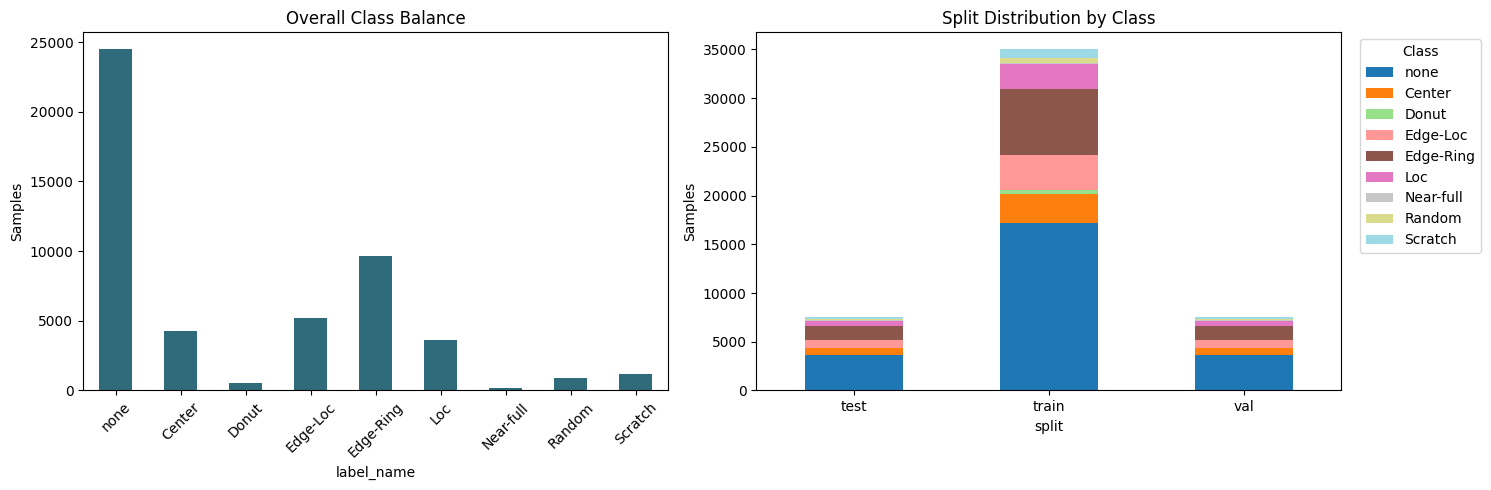

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

summary["count"].plot(kind="bar", ax=axes[0], color="#2F6B7A")
axes[0].set_title("Overall Class Balance")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=45)

metadata.groupby(["split", "label_name"]).size().unstack(fill_value=0).reindex(columns=class_names).plot(
    kind="bar", stacked=True, ax=axes[1], colormap="tab20"
)
axes[1].set_title("Split Distribution by Class")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Training Behavior

In [9]:
history.tail()

,epoch,train_loss,train_accuracy,train_balanced_accuracy,train_eval_loss,train_eval_accuracy,train_eval_balanced_accuracy,val_loss,val_accuracy,val_balanced_accuracy,learning_rate
43,44,0.376005,0.959943,0.959412,0.403304,0.946629,0.958257,0.429245,0.937467,0.922392,0.000125
44,45,0.378417,0.960486,0.960493,0.394930,0.949829,0.959612,0.424770,0.935067,0.920067,0.000063
45,46,0.373900,0.961457,0.961480,0.389950,0.951743,0.962517,0.416324,0.942000,0.932019,0.000063
46,47,0.366652,0.965143,0.965205,0.395908,0.949457,0.963980,0.425056,0.936800,0.928732,0.000063
47,48,0.369086,0.964171,0.964319,0.398879,0.948286,0.964566,0.434158,0.933467,0.926099,0.000063


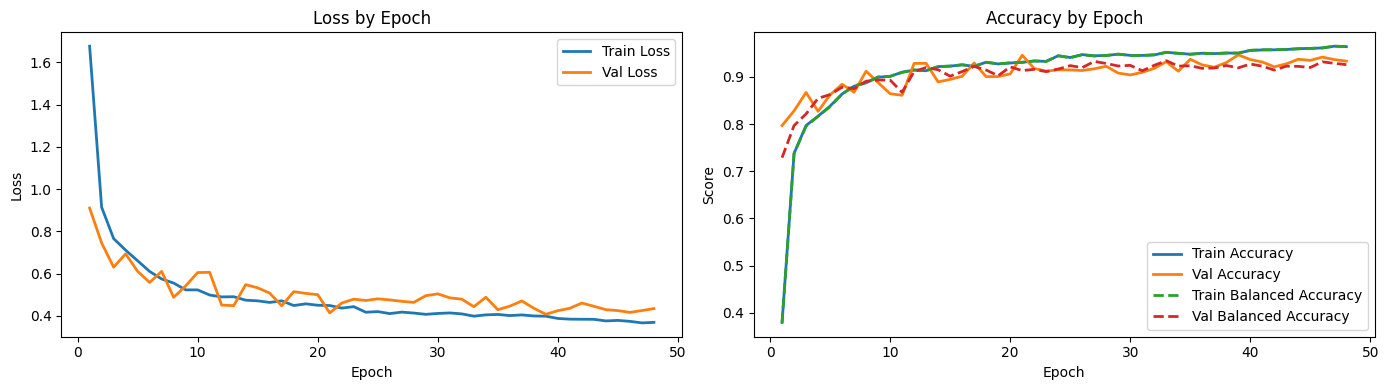

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history["epoch"], history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].plot(history["epoch"], history["train_balanced_accuracy"], label="Train Balanced Accuracy", linewidth=2, linestyle="--")
axes[1].plot(history["epoch"], history["val_balanced_accuracy"], label="Val Balanced Accuracy", linewidth=2, linestyle="--")
axes[1].set_title("Accuracy by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Held-Out Test Performance

In [11]:
headline_metrics = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": metrics["train"]["accuracy"],
            "balanced_accuracy": metrics["train"]["balanced_accuracy"],
        },
        {
            "split": "val",
            "accuracy": metrics["val"]["accuracy"],
            "balanced_accuracy": metrics["val"]["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": metrics["test"]["accuracy"],
            "balanced_accuracy": metrics["test"]["balanced_accuracy"],
        },
    ]
)
headline_metrics

,split,accuracy,balanced_accuracy
0,train,0.936429,0.948761
1,val,0.932267,0.934457
2,test,0.935067,0.936327


In [12]:
test_report = pd.DataFrame(metrics["test"]["classification_report"]).T
class_report = test_report.loc[class_names, ["precision", "recall", "f1-score", "support"]]
class_report.sort_values("f1-score", ascending=False)

,precision,recall,f1-score,support
Edge-Ring,0.978290,0.993113,0.985646,1452.0
none,0.989559,0.929194,0.958427,3672.0
Random,0.983740,0.930769,0.956522,130.0
Center,0.905523,0.967391,0.935435,644.0
Donut,0.866667,0.939759,0.901734,83.0
Near-full,0.814815,1.000000,0.897959,22.0
Edge-Loc,0.877215,0.889602,0.883365,779.0
Loc,0.811052,0.844156,0.827273,539.0
Scratch,0.558528,0.932961,0.698745,179.0


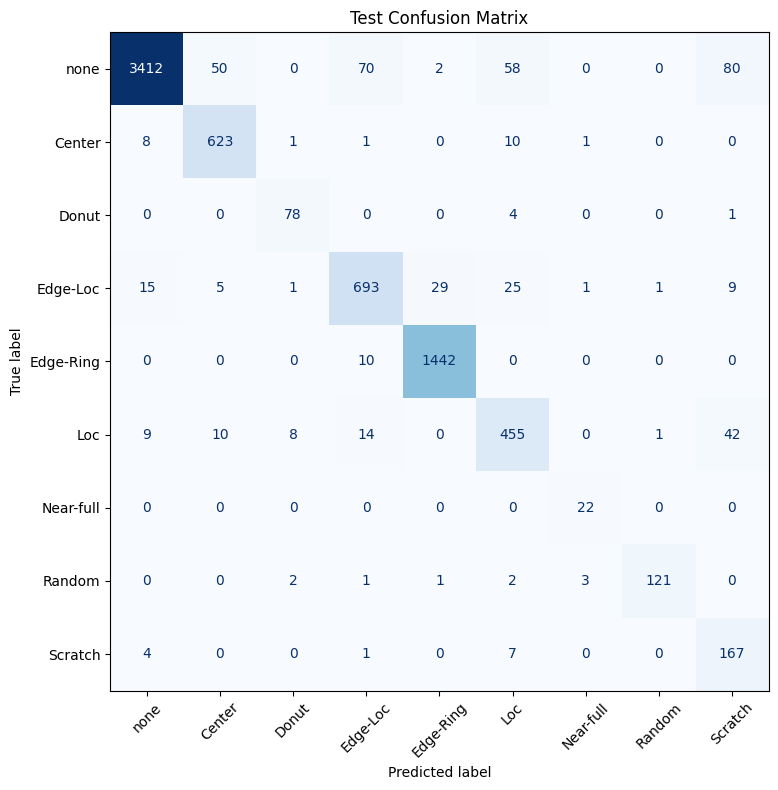

In [13]:
cm = confusion_matrix(
    test_predictions["target_label"],
    test_predictions["predicted_label"],
    labels=class_names,
)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Example Test Predictions

In [14]:
test_metadata = metadata[metadata["split"] == "test"].reset_index(drop=True).copy()
test_display = test_metadata.join(test_predictions[["predicted_label", "confidence"]])
test_display["correct"] = test_display["label_name"] == test_display["predicted_label"]

correct_examples = test_display[test_display["correct"]].sort_values("confidence", ascending=False).head(6)
error_examples = test_display[~test_display["correct"]].sort_values("confidence", ascending=False).head(6)

print(f"Correct examples shown: {len(correct_examples)}")
print(f"Incorrect examples shown: {len(error_examples)}")

Correct examples shown: 6
Incorrect examples shown: 6


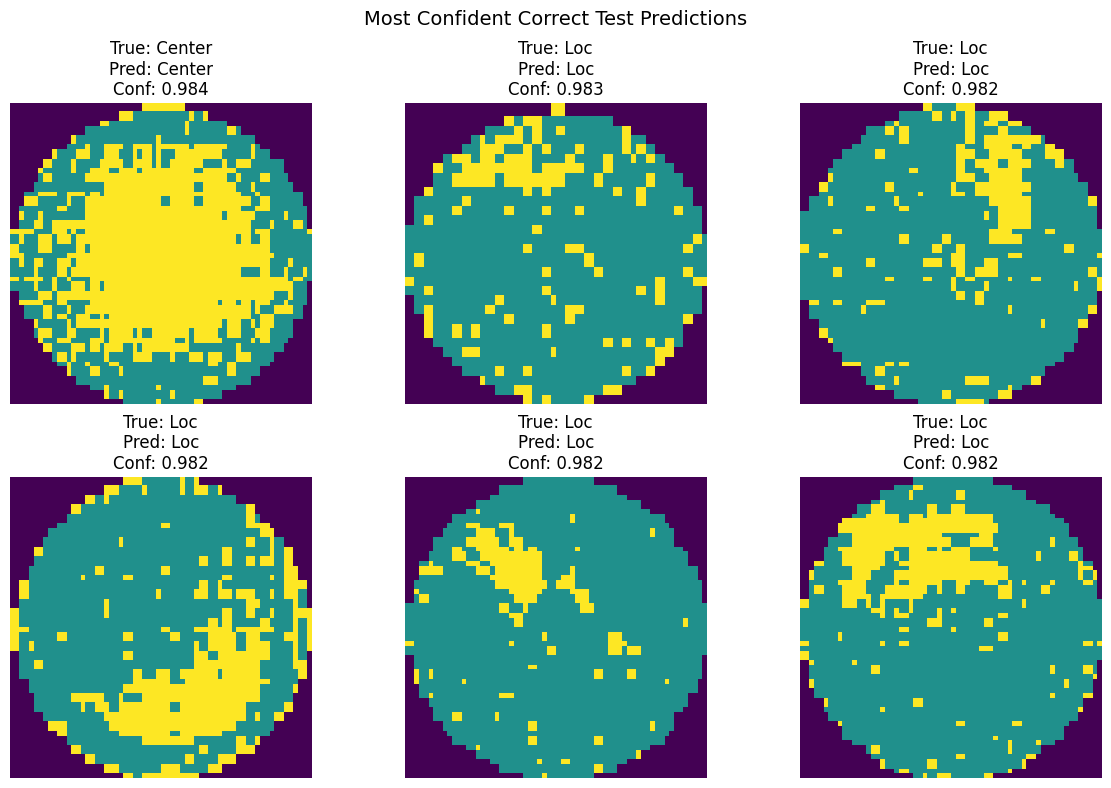

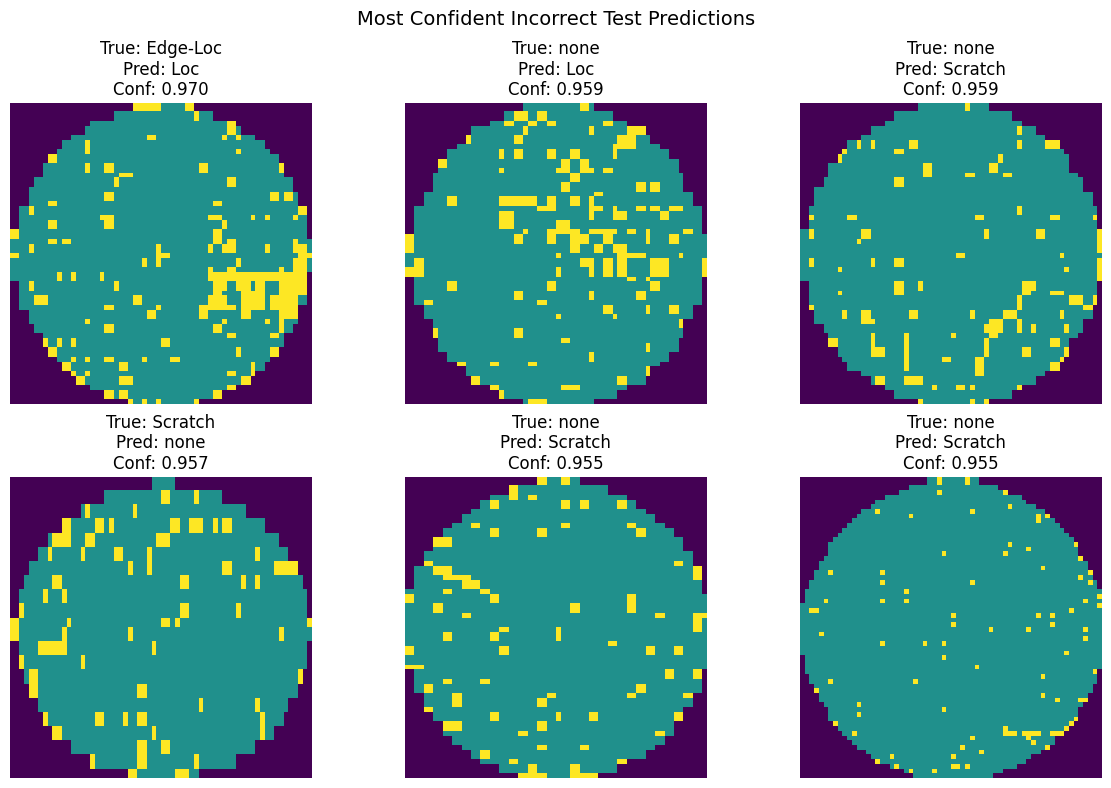

In [15]:
def load_map(array_path: str) -> np.ndarray:
    return np.load(REPO_ROOT / array_path)

def plot_examples(frame: pd.DataFrame, title: str) -> None:
    if frame.empty:
        print(f"No rows available for {title.lower()}.")
        return
    columns = min(3, len(frame))
    rows = int(np.ceil(len(frame) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, frame.iterrows()):
        ax.imshow(load_map(row["array_path"]), cmap="viridis")
        ax.set_title(
            f"True: {row['label_name']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.3f}"
        )
        ax.axis("off")
    for ax in axes[len(frame):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_examples(correct_examples, "Most Confident Correct Test Predictions")
plot_examples(error_examples, "Most Confident Incorrect Test Predictions")

## Unlabeled Data Labeling

In [16]:
if unlabeled_predictions is None:
    print("No unlabeled prediction file found yet. Run scripts/classifier/predict_unlabeled_multiclass.py first.")
else:
    print(f"Unlabeled rows labeled: {len(unlabeled_predictions):,}")
    display(unlabeled_predictions.head())

No unlabeled prediction file found yet. Run scripts/classifier/predict_unlabeled_multiclass.py first.


In [17]:
if unlabeled_predictions is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    unlabeled_predictions["predicted_label"].value_counts().reindex(class_names, fill_value=0).plot(
        kind="bar", ax=axes[0], color="#B56576"
    )
    axes[0].set_title("Predicted Labels on Unlabeled Data")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].hist(unlabeled_predictions["confidence"], bins=30, color="#355070", edgecolor="white")
    axes[1].set_title("Prediction Confidence Distribution")
    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Rows")

    plt.tight_layout()
    plt.show()

In [18]:
if unlabeled_predictions is not None:
    uncertain = unlabeled_predictions.sort_values("confidence", ascending=True).head(10)
    confident = unlabeled_predictions.sort_values("confidence", ascending=False).head(10)
    print("Most uncertain unlabeled predictions")
    display(uncertain)
    print("Most confident unlabeled predictions")
    display(confident)